## Homework 03: Exploratory Data Analysis and Feature Engineering

#### Due Date: Sunday, September 20th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 603 Syllabus. 

### Introduction

In this homework, you will apply the exploratory data analysis and data preparation techniques from Week 3 to the **Ames Housing dataset**, a real dataset describing residential property sales in Ames, Iowa. Compared with the simplified dataset used in the lesson, Ames contains many more features and presents a wider range of issues involving feature types, missing values, skewed distributions, categorical variables, correlated features, and unusual observations.

The goal is not simply to “clean” the data according to a fixed set of rules. Instead, you will use EDA to identify characteristics of the data that may affect modeling and to make reasonable preprocessing choices. Some of these choices may later turn out to improve a predictive model, while others may not; an important theme of this homework is that preprocessing decisions should ultimately be evaluated through model performance.

> You are **not expected to write Pandas code from scratch**. For the following questions, reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.
>
> The Pandas Appendix from Homework 2 has been included below to help with Pandas functions. 


### Grading

- All homeworks in DX 603 are worth **80 points**.
- This homework has **8 problems, each worth 10 points**.
- Multi-part problems will have approximately equal points for each subpart. 

You may submit a regrade request on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.

In [137]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mtick

import random
import statistics
import math

random_seed = 42

import os
import requests
import pandas as pd

In [138]:


# ==================================================
# Download the Ames Housing data and documentation
# ==================================================

files = {
    "AmesHousing.txt"       : "https://jse.amstat.org/v19n3/decock/AmesHousing.txt",
    "DataDocumentation.txt" : "https://jse.amstat.org/v19n3/decock/DataDocumentation.txt"
}

for filename, url in files.items():
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        response = requests.get(url)
        response.raise_for_status()

        with open(filename, "wb") as f:
            f.write(response.content)

        print(f"{filename} downloaded.")
    else:
        print(f"{filename} already exists. Skipping download.")

# ==================================================
# Load the TXT file into a Pandas DataFrame
# ==================================================

df = pd.read_csv("AmesHousing.txt", sep="\t")

df.head()

AmesHousing.txt already exists. Skipping download.
DataDocumentation.txt already exists. Skipping download.


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Problem 1: First Look at the Ames Housing Dataset

In this homework, we will work with the **Ames Housing dataset**, which contains information about residential properties sold in Ames, Iowa. 

The code above loads the dataset directly from its original source into a Pandas DataFrame.

You are **not expected to write Pandas code from scratch**. For the following questions, reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.

### Part A Graded Answer: Number of Observations

Use `df.shape` to determine how many observations (rows) are in the dataset.

Assign:

    a1a = number of rows


In [139]:
# Your code here



In [140]:
# Your answer here, NOT in the next cell

a1a = df.shape[0]             # Replace with an expression that returns the number of rows


In [141]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1a = {a1a}')

a1a = 2930


### Part B Graded Answer: Stored Data Types

Use `.info()` or `.dtypes` to examine how the columns are stored by Pandas.

Assign:

    a1b = number of columns stored as type object

**Hint:** After examining `df.dtypes` (a Series), use a Series method that counts how often each distinct value occurs (see the Appendix). 

In [142]:
# Your code here, add more cells as needed

df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning             str
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type             str
Sale Condition        str
SalePrice           int64
Length: 82, dtype: object

In [143]:
# Your answer here, NOT in the next cell

a1b = len(df.select_dtypes(include = ['string','object']).columns)             # Replace with an expression that returns the number of columns

In [144]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1b = {a1b}')

a1b = 43


### Part C Graded Answer: Pandas Data Type

Look at the feature `MS SubClass` in the dataset.

Assign:

    a1c = Pandas Dtype of MS SubClass (as a string)


In [145]:
# Your answer here, NOT in the next cell

a1c = df['MS SubClass'].dtype            # Replace with the Pandas/Python type of MS Subclass (as a string)

In [146]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1c = {a1c}')

a1c = int64


### Part D Graded Answer: Data Type Is Not Feature Type

Now find the description of `MS SubClass` in `DataDocumentation.txt`.

Assign:

    a1d = feature type given in the documentation

Use one of these strings:

```python
"Nominal"
"Ordinal"
"Discrete"
"Continuous"
```

> This illustrates an important distinction: a feature may be stored numerically by Pandas even though the numbers are actually category labels.


In [147]:
# Your answer here, NOT in the next cell

a1d = "Nominal"            # Replace with the Pandas/Python type of MS Subclass (as a string)

In [148]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1d = {a1d}')

a1d = Nominal


## Problem 2: Investigating Missing Data

Real datasets often contain missing values. Before deciding how to handle them, we first need to determine **where the missing values occur and how common they are**.

You are **not expected to write Pandas code from scratch**. For the following questions, reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.


### Part A Graded Answer: Features with Missing Values

Use Pandas to determine how many columns contain **at least one missing value**.

A useful starting point is:

```python
df.isna().sum()
```

Assign:

    a2a = number of columns containing at least one missing value

**Hint:** `df.isna().sum()` produces a Series containing the number of missing values in each column. Think about how you could determine how many of those values are greater than zero.


In [149]:
# Your code here, add more cells as needed

number_of_missing_values = df.isna().sum() 
number_of_cols_with_missing_values = len(number_of_missing_values[number_of_missing_values>0])

In [150]:
# Your answer here, NOT in the next cell

a2a = number_of_cols_with_missing_values              # Replace with an expression that returns the number of columns containing missing values


In [151]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a}')


a2a = 27


### Part B Graded Answer: Features with Substantial Missingness

Determine how many columns have more than 20% of their values missing.

Assign:

    a2b = number of columns with more than 20% of their values missing.

In solutions, always give percentages as a float between 0 and 1.0, i.e., 0.345, not 34.5%. 

**Hint:** First compute the missing fraction for every column. Then compare those fractions with 0.20.


In [152]:
# Your code here, add more cells as needed

missing_fractions = df.isna().sum()/len(df)
greater_than_20 = len(missing_fractions[missing_fractions > .20])

In [153]:
# Your answer here, NOT in the next cell

a2b = greater_than_20           # Replace with an expression that returns the number of columns with more than 20% missingness.


In [154]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b}')


a2b = 6


### Part C Graded Answer: What Does "Missing" Mean?

Now consult the **Ames Housing data documentation** you downloaded along with the dataset. 

The feature `Alley` contains a very large number of missing values in the DataFrame. According to the documentation, what does `NA` mean for this feature?

Assign:

    a2c = your answer

Use one of the following strings:

```python
"Unknown"
"No alley access"
"Not recorded"
```


In [155]:
# Your answer here, NOT in the next cell

a2c = "No alley access"             # Replace with one of the strings listed above


In [156]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2c = {a2c}')


a2c = No alley access


## Problem 3: Exploring Feature Distributions

In the Week 3 lesson, we used summary statistics and visualizations to understand the distributions of individual features. In this problem, you will apply the same ideas to several important features in the Ames Housing dataset.

You are **not expected to write Pandas or plotting code from scratch**. Reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.


### Part A Graded Answer: Shape of the Sale Price Distribution

Create a histogram of `SalePrice`, using code from the Week 3 Coding Notebook as a model.

Based on the histogram, characterize the overall shape of the distribution.

Assign:

    a3a = overall shape

Use one of the following strings:

```python
"right-skewed"
"left-skewed"
"approximately symmetric"
```


<Axes: >

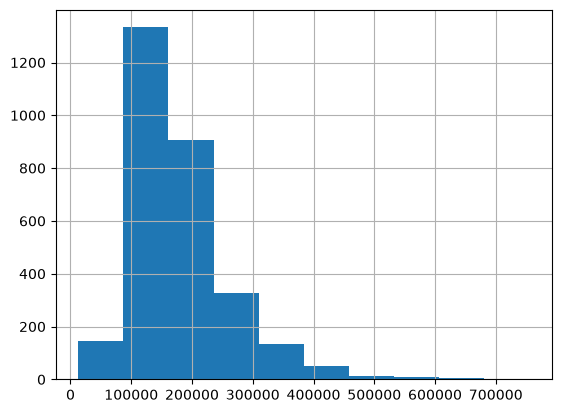

In [157]:
# Your code here, add more cells as needed

df.SalePrice.hist()

In [158]:
# Your answer here, NOT in the next cell

a3a = "right-skewed"             # Replace with one of the strings listed above


In [159]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')


a3a = right-skewed


### Part B Graded Answer: Comparing Skewness

Compare the distributions of these three continuous variables:

- `SalePrice`
- `Gr Liv Area`
- `Lot Area`

Use Pandas to calculate the **skewness** of each feature.

Assign:

    a3b = name of the feature with the greatest positive skewness

Use the column name exactly as it appears in the dataset.

**Hint:** You can select several columns at once and then apply `.skew()` to the resulting DataFrame.


In [160]:
# Your code here, add more cells as needed

df[['SalePrice', 'Gr Liv Area','Lot Area']].skew()


SalePrice       1.743500
Gr Liv Area     1.274110
Lot Area       12.820898
dtype: float64

In [161]:
# Your answer here, NOT in the next cell

a3b = "Lot Area"             # Replace with the exact column name


In [162]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')


a3b = Lot Area


### Part C Graded Answer: Effect of a Log Transformation

`Lot Area` is highly right-skewed. A log transformation is one possible way to make a strongly skewed distribution more symmetric.

Apply a base-10 log transformation to `Lot Area`, then calculate the skewness of the transformed values.

Assign:

    a3c = skewness after the log10 transformation

**Hint:** Use `np.log10()` to perform the transformation and `.skew()` to measure the skewness afterward.

Do **not** replace the original `Lot Area` column; create a temporary Series or a new variable for this investigation.


In [163]:
# Your code here, add more cells as needed

Lot_Area_Transformed= np.log10(df['Lot Area'])


In [164]:
# Your answer here, NOT in the next cell

a3c = Lot_Area_Transformed.skew()           # Replace with an expression that returns the skewness


In [165]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3c = {a3c}')


a3c = -0.49886098943432977


## Problem 4: Investigating Relationships and Unusual Observations

Exploratory data analysis also helps us understand how features are related to one another and to the target. In this problem, you will use correlations and a scatterplot to investigate several relationships in the Ames Housing data.

You will also examine a small group of unusually large houses. Remember that an unusual observation is not automatically an error and should not automatically be removed.

You are **not expected to write Pandas or plotting code from scratch**. Reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.


### Part A Graded Answer: Correlation with Sale Price

Calculate the correlation between `Gr Liv Area` (above-ground living area) and `SalePrice`.

Assign:

    a4a = correlation between "Gr Liv Area" and "SalePrice"

**Hint:** You can select the two columns and use `.corr()` to create a small correlation matrix.


In [166]:
# Your code here, add more cells as needed

coorelation = df['Gr Liv Area'].corr(df["SalePrice"])

In [167]:
# Your answer here, NOT in the next cell

a4a = coorelation           # Replace with an expression that returns the correlation


In [168]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4a = {a4a}')


a4a = 0.7067799209766279


### Part B Graded Answer: Strongest Numerical Relationship with the Target

Consider the **numerical features** in the dataset, but ignore the two identifier columns `Order` and `PID`.

Calculate the correlation of each numerical feature with `SalePrice`. Which feature has the **largest positive correlation** with the target?

Assign:

    a4b = name of the feature with the largest positive correlation with "SalePrice"

Do not include `SalePrice` itself.

**Hint:** One approach is to use `select_dtypes(include="number")`, then calculate `.corr()` and examine the `SalePrice` column of the resulting correlation matrix.


In [228]:
# Your code here, add more cells as needed

corr_with_sales_price = df.select_dtypes(include = 'number').drop(columns = ['Order', 'PID']).corr()['SalePrice']
#remove saleprice
corr_with_sales_price = corr_with_sales_price.drop('SalePrice')

largest_corr_feature = corr_with_sales_price.idxmax()

In [229]:
# Your answer here, NOT in the next cell

a4b = largest_corr_feature             # Replace with the exact column name


In [230]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4b = {a4b}')


a4b = Overall Qual


### Part C Graded Answer: Unusually Large Houses

The Ames Housing documentation calls attention to a small number of houses with more than **4,000 square feet of above-ground living area**.

Determine how many observations satisfy:

```python
Gr Liv Area > 4000
```

Assign:

    a4c = number of observations with "Gr Liv Area" greater than 4000

**Hint:** Create a Boolean condition and use `.sum()` to count the `True` values.


In [234]:
# Your code here, add more cells as needed

number_of_obsv = len(df[df['Gr Liv Area'] > 4000]) 


In [237]:
# Your answer here, NOT in the next cell

a4c = number_of_obsv              # Replace with an expression that returns the number of observations


In [238]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4c = {a4c}')


a4c = 5


### Part D Graded Answer: Looking More Closely at the Unusual Houses

Now examine the observations with `Gr Liv Area > 4000`.

Display at least these columns for those houses:

```python
["Gr Liv Area", "SalePrice", "Sale Condition"]
```

How many of these unusually large houses have `Sale Condition` equal to `"Partial"`?

Assign:

    a4d = number of unusually large houses with Sale Condition "Partial"

**Hint:** You can combine two Boolean conditions using `&`. Put each condition inside parentheses.


In [246]:
# Your code here, add more cells as needed

large_houses = df[df['Gr Liv Area'] > 4000][["Gr Liv Area", "SalePrice", "Sale Condition"]]
num_partial = (large_houses['Sale Condition'] == 'Partial').sum()

In [247]:
# Your answer here, NOT in the next cell

a4d = num_partial              # Replace with an expression that returns the number of observations


In [248]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4d = {a4d}')


a4d = 3


## Problem 5: Categorical Features and Encoding

Many machine learning models require numerical inputs, so categorical features often need to be encoded before modeling. In the Ames Housing dataset, `Neighborhood` is a **nominal** feature: its values identify locations, but the categories have no natural numerical ordering.

In this problem, you will investigate three possible ways of handling a categorical feature:

- one-hot encoding;
- frequency encoding;
- grouping rare categories before encoding.

You are **not expected to write Pandas code from scratch**. Reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.


### Part A Graded Answer: One-Hot Encoding

`Neighborhood` is a nominal categorical feature. One-hot encoding creates a separate indicator column for each category.

Use `pd.get_dummies()` to one-hot encode `Neighborhood`. Do **not** drop any category for this investigation.

Assign:

    a5a = number of columns created by one-hot encoding "Neighborhood"

**Hint:** After creating the encoded DataFrame, use `.shape` to determine how many columns it contains.


In [258]:
# Your code here, add more cells as needed

num_cols_neighborhood_encoded = pd.get_dummies(df['Neighborhood'], drop_first= False).shape[1]


In [259]:
# Your answer here, NOT in the next cell

a5a = num_cols_neighborhood_encoded              # Replace with an expression that returns the number of encoded columns


In [260]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5a = {a5a}')


a5a = 28


### Part B Graded Answer: Frequency Encoding

Frequency encoding represents each category by how often it occurs in the dataset.

The following expression gives the proportion of observations belonging to each neighborhood:

```python
neighborhood_freq = df["Neighborhood"].value_counts(normalize=True)
```

Assign:

    a5b = frequency-encoded value for the most common neighborhood

Give the answer as a proportion between 0 and 1, not as a percentage.


In [266]:
# Your code here, add more cells as needed

neighborhood_freq = df["Neighborhood"].value_counts(normalize=True)

fev = neighborhood_freq.max()

In [267]:
# Your answer here, NOT in the next cell

a5b = fev            # Replace with an expression that returns the frequency of the most common neighborhood


In [268]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5b = {a5b}')


a5b = 0.15119453924914675


### Part C Graded Answer: Grouping Rare Categories

Another possible strategy is to combine very uncommon categories into a single category such as `"Other"` before one-hot encoding.

For this investigation, define a **rare neighborhood** as one containing **less than 1% of the observations**.

Use the neighborhood frequencies from Part B to identify the rare neighborhoods. Then replace those neighborhood names with `"Other"` in a temporary Series.

Assign:

    a5c = number of unique categories after grouping all neighborhoods below 1% into "Other"

Create a new temporary Series containing the grouped neighborhood values. Do not overwrite df["Neighborhood"].

**Hint:** You can use `.isin()` to identify values belonging to a collection of rare categories, and `.where()` to replace the others.


In [300]:
# Your code here, add more cells as needed
other_indexes = neighborhood_freq[neighborhood_freq < .01].index
other_mask = neighborhood_freq.index.isin(other_indexes)
new_series_neighborhoods = neighborhood_freq.index.where(~other_mask, "Other")

In [301]:
# Your answer here, NOT in the next cell

a5c = new_series_neighborhoods.nunique()              # Replace with an expression that returns the number of categories after grouping


In [302]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5c = {a5c}')


a5c = 22


## Problem 6: From EDA to Data Preparation

In the previous problems, you identified several characteristics of the Ames Housing data that could affect modeling. In this problem, you will apply a few simple preparation steps and investigate one possible source of redundancy.

These steps should be viewed as **reasonable candidate choices**, not as rules that are guaranteed to improve a model. Later in the course, once we have models and validation methods, we can test whether preprocessing choices actually improve predictive performance.

You are **not expected to write Pandas code from scratch**. Reuse and adapt code from the Week 3 Coding Notebook, or use AI to help you generate or modify the code.


### Part A Graded Answer: Remove Identifier Columns

The columns `Order` and `PID` identify observations rather than describing characteristics of a house that we want a model to learn from.

Create a new DataFrame called `df_prepared` by dropping these two columns from `df`.

Assign:

    a6a = number of columns in df_prepared

**Hint:** Use `.drop(columns=[...])`, then examine `.shape`.


In [309]:
# Your code here, add more cells as needed

df_prepared = df.drop(columns = ['Order', 'PID'])


In [310]:
# Your answer here, NOT in the next cell

a6a = len(df_prepared.columns)           # Replace with an expression that returns the number of columns


In [311]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6a = {a6a}')


a6a = 80


### Part B Graded Answer: Imputing a Numerical Feature

`Lot Frontage` is a numerical feature with some missing values. It is also right-skewed, so the **median** is a reasonable simple value to investigate for imputation.

Find the median of the non-missing values in `Lot Frontage`.

Assign:

    a6b = median value of "Lot Frontage"

Then use that value with `.fillna()` to create a temporary version of `Lot Frontage` with no missing values.

**Hint:** The Pandas `.median()` method ignores missing values by default.


In [323]:
# Your code here, add more cells as needed
lot_frontage_median = df_prepared['Lot Frontage'].median()
temp_series_lot_frontage = df_prepared['Lot Frontage'].fillna(lot_frontage_median)

In [324]:
# Your answer here, NOT in the next cell

a6b = lot_frontage_median           # Replace with an expression that returns the median


In [325]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6b = {a6b}')


a6b = 68.0


### Part C Graded Answer: Looking for Redundant Features

Two features that measure closely related aspects of a house may contain largely overlapping information.

Calculate the correlation for each of these pairs:

- `Garage Cars` and `Garage Area`
- `1st Flr SF` and `Total Bsmt SF`
- `Gr Liv Area` and `TotRms AbvGrd`

Which pair has the **largest correlation**?

Assign:

    a6c = pair with largest correlation

Use one of the following strings exactly:

```python
"Garage Cars / Garage Area"
"1st Flr SF / Total Bsmt SF"
"Gr Liv Area / TotRms AbvGrd"
```


In [335]:
# Your code here, add more cells as needed
corr_dict= {}
corr_dict['Garage Cars / Garage Area'] = df_prepared['Garage Cars'].corr(df_prepared['Garage Area'])
corr_dict['1st Flr SF / Total Bsmt SF'] = df_prepared['1st Flr SF'].corr(df_prepared['Total Bsmt SF'])
corr_dict["Gr Liv Area / TotRms AbvGrd"] = df_prepared['Gr Liv Area'].corr(df_prepared['TotRms AbvGrd'])
pair_largest_corr = max(corr_dict, key =corr_dict.get)

In [352]:
corr_dict

{'Garage Cars / Garage Area': np.float64(0.8896762825411677),
 '1st Flr SF / Total Bsmt SF': np.float64(0.8007203902506768),
 'Gr Liv Area / TotRms AbvGrd': np.float64(0.8077721448904693)}

In [ ]:
# Your answer here, NOT in the next cell

a6c = pair_largest_corr         # Replace with one of the strings listed above


In [337]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6c = {a6c}')


a6c = Garage Cars / Garage Area


## Problem 7: Multiple Choice

For each question, assign the number of the **best answer** to the corresponding variable.


### Part A Graded Answer: Data Type vs. Feature Type

Suppose a feature contains the values `20`, `30`, `40`, `50`, and `60`, and the documentation explains that these numbers are codes representing different types of houses.

How should this feature be treated?

1. As a continuous numerical feature, because the values are numbers.
2. As a discrete numerical feature, because the values are integers.
3. As a nominal categorical feature, because the numbers represent labels with no meaningful numerical distance.
4. As an ordinal feature, because 60 is greater than 20.


In [338]:
# Your answer here, NOT in the next cell

a7a = 3              # Replace with 1, 2, 3, or 4


In [339]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7a = {a7a}')


a7a = 3


### Part B Graded Answer: Interpreting Missing Values

In the Ames data, most values of `Pool QC` appear as missing in the DataFrame. The documentation indicates that `NA` usually means that the house has no pool.

What is the best conclusion?

1. `Pool QC` should automatically be dropped because more than 90% of its values are missing.
2. All missing values should be replaced by the most common non-missing pool quality.
3. The apparent missingness contains information and should be represented as a category such as `"No Pool"`.
4. Houses without pools should be removed from the dataset.


In [342]:
# Your answer here, NOT in the next cell

a7b = 3              # Replace with 1, 2, 3, or 4


In [343]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7b = {a7b}')


a7b = 3


### Part C Graded Answer: Transforming a Skewed Feature

You find that `Lot Area` is strongly right-skewed. Applying a logarithmic transformation makes its distribution much more symmetric.

Which conclusion is most appropriate?

1. The log-transformed version must produce a better predictive model.
2. The original feature should be deleted because it was skewed.
3. The transformation is a reasonable preprocessing idea, but whether it improves prediction must eventually be tested with a model.
4. Every continuous feature in the dataset should now be log-transformed.


In [344]:
# Your answer here, NOT in the next cell

a7c = 3              # Replace with 1, 2, 3, or 4


In [346]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7c = {a7c}')


a7c = 3


### Part D Graded Answer: Correlation and Redundancy

Suppose two housing features have a correlation of `0.90`.

What is the strongest conclusion you can draw from this information alone?

1. One of the features must be removed.
2. The two features contain substantially overlapping linear information and should be investigated for possible redundancy.
3. One feature causes the other.
4. Both features will necessarily have equally strong relationships with `SalePrice`.


In [347]:
# Your answer here, NOT in the next cell

a7d = 2              # Replace with 1, 2, 3, or 4


In [348]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7d = {a7d}')


a7d = 2


### Part E Graded Answer: Outliers and Modeling Goals

A scatterplot of `Gr Liv Area` versus `SalePrice` reveals several houses that are much larger than nearly all the others.

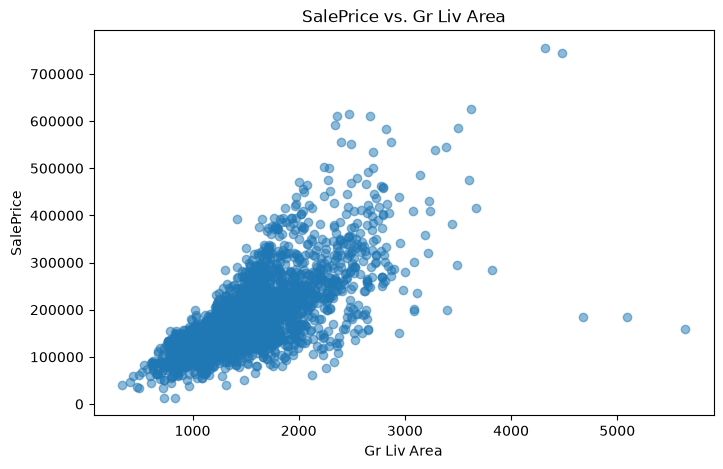

In [349]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["Gr Liv Area"], df["SalePrice"], alpha=0.5)

plt.title("SalePrice vs. Gr Liv Area")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")

plt.show()

What is the most appropriate next step?

1. Delete them immediately because outliers always reduce model quality.
2. Keep them permanently because real observations should never be removed.
3. Investigate the observations and consider whether they belong to the population the model is intended to predict before deciding what to do with them.
4. Replace their values with the median values of the corresponding features.

In [350]:
# Your answer here, NOT in the next cell

a7e = 3              # Replace with 1, 2, 3, or 4


In [351]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7e = {a7e}')


a7e = 3


## Problem 8: Reflection

In this homework, you explored several issues that arise when preparing real data for machine learning, including missing values, skewed features, categorical variables, correlated features, and unusual observations.

Choose **one issue from the homework** that you think would be especially important before building a model to predict `SalePrice`. In **one paragraph of about 4–5 sentences**, describe what you found, explain what preprocessing or modeling decision it suggests, and explain why that decision is not guaranteed to improve the final model. Conclude by stating how you would evaluate the choice later once you have learned how to build and compare predictive models.


In [353]:
# Your answer here, NOT in the next cell

a8 = """
I think it would be especially important to remove columns that are highly correlated and therefore potentially redundant. In the homework I discoved 
that the following columns had the following correlations that were all greater than .8: 'Garage Cars / Garage Area': np.float64(0.8896762825411677),
'1st Flr SF / Total Bsmt SF': np.float64(0.8007203902506768, and 'Gr Liv Area / TotRms AbvGrd': np.float64(0.8077721448904693)}. This finding suggests 
that we do not need all six of these columns for our model, because all three pairs contain overlapping linear information. 
That decision is not garunteed to produce a better model because different models treat redundancy differently and we don't know yet what kind 
of model we are going to use. Once I learn how to build and compare predictive models I would compare performance with all the columns versus 
training with different combinations of the redundant ones being removed.  
"""


In [354]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a8 =")
print(a8)

a8 =

I think it would be especially important to remove columns that are highly correlated and therefore potentially redundant. In the homework I discoved 
that the following columns had the following correlations that were all greater than .8: 'Garage Cars / Garage Area': np.float64(0.8896762825411677),
'1st Flr SF / Total Bsmt SF': np.float64(0.8007203902506768, and 'Gr Liv Area / TotRms AbvGrd': np.float64(0.8077721448904693)}. This finding suggests 
that we do not need all six of these columns for our model, because all three pairs contain overlapping linear information. 
That decision is not garunteed to produce a better model because different models treat redundancy differently and we don't know yet what kind 
of model we are going to use. Once I learn how to build and compare predictive models I would compare performance with all the columns versus 
training with different combinations of the redundant ones being removed.  



## Appendix: Useful Pandas Series Methods

You are **not expected to memorize all Pandas commands**. When you know what kind of operation you want to perform, use this table or the Pandas documentation to find an appropriate method.

Assume that `x` is a Pandas Series.

| Method or expression | Purpose |
|---|---|
| `x.head()` | Display the first few values |
| `x.tail()` | Display the last few values |
| `x.min()` | Return the minimum value |
| `x.max()` | Return the maximum value |
| `x.quantile(0.25)` | Calculate the 0.25 quantile (first quartile); replace `0.25` with another quantile as needed |
| `x.idxmin()` | Return the index label of the minimum value |
| `x.idxmax()` | Return the index label of the maximum value |
| `x.mean()` | Return the arithmetic mean |
| `x.median()` | Return the median |
| `x.mode()` | Return the mode(s) |
| `x.std()` | Return the standard deviation |
| `x.nunique()` | Count the number of distinct values |
| `x.value_counts()` | Count how many times each distinct value occurs |
| `x.sort_values()` | Return the values sorted from smallest to largest |
| `x.sort_values(ascending=False)` | Return the values sorted from largest to smallest |
| `x.describe()` | Return several common descriptive statistics |
| `x.iloc[k]` | Return the value at position `k` |
| `x.iloc[-k]` | Return the value `k` positions from the end (`x.iloc[-1]` is the last value) |
| `x.iloc[a:b]` | Return values from positions `a` through `b-1` |
| `x.hist(bins=20)` | Create a histogram of the values with 20 bins (insert appropriate number)|

### A note about `iloc`

A Pandas Series differs from a Python list because each value has an associated **index label**. As a result, `x.iloc[k]` and `x[k]` do not necessarily refer to the same value.

* `x.iloc[k]` selects the value at **position** `k`.
* `x[k]` selects the value with **index label** `k`.

For example, `x.iloc[0]` always returns the first value in the Series, regardless of its index label.

Similarly:

* `x.iloc[-1]` returns the last value.
* `x.iloc[0:5]` returns the first five values.

**Summary:** Use `iloc` when you want to select values by their **position**, as you would with a Python list.
